# Rolling Temporal Validation for NBA Shot Quality Model

## Overview

This notebook performs **rolling temporal validation** to test how well our shot quality model generalizes across NBA seasons. Unlike standard cross-validation, this approach:

1. Trains on historical seasons
2. Tests on the next season (simulating real deployment)
3. Measures how model performance holds up over time

## Latest Updates (December 2025)

### Model
- **Primary Model**: LightGBM (best performer at 66.73% AUC in main notebook)
- **Hyperparameters**: Pre-tuned from Bayesian optimization in main notebook

### Features (62 total, matching main notebook)
- **Base Features**: shotDistance, shot_clock, coordinates, period, contest_score
- **Shot Clock x Location Interactions**: 13 features (is_transition_paint, is_desperation_3pt, etc.)
- **Text-Parsed Features**: pullup, stepback, fadeaway, driving, floating, etc.
- **Court Zone Features**: is_paint, is_corner3, is_above_break3, is_midrange
- **Granular Shot Clock Buckets**: 0-4s, 4-8s, 8-12s, 12-16s, 16-20s, 20-24s
- **Prior Season Player Stats**: prior_fg_pct, prior_fg3_pct, prior_fg2_pct, prior_attempts
- **Opponent Defensive Stats**: opp_def_fg_pct, opp_def_rim_pct, opp_def_3pt_pct

### Configuration
- `RANDOM_STATE = 42`
- Rolling folds: Train on prior years -> Test on next year
- Prior stats loaded from `player_historical_stats.csv` and `team_defensive_stats.csv`

### Expected Performance
- **Typical AUC**: 0.66-0.70 (with prior season features)
- **Performance may vary** by season due to rule changes, play style evolution

In [8]:
import pandas as pd
import numpy as np
import os
import re
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, log_loss, brier_score_loss, accuracy_score
import matplotlib.pyplot as plt

# Optional imports
try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_AVAILABLE = True
except ImportError:
    LIGHTGBM_AVAILABLE = False
    print("LightGBM not available. Install: pip install lightgbm")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False

# Configuration
RANDOM_STATE = 42

# Best LightGBM hyperparameters from main notebook
BEST_LGBM_PARAMS = {
    'n_estimators': 563,
    'max_depth': 8,
    'learning_rate': 0.0117,
    'num_leaves': 84,
    'subsample': 0.668,
    'colsample_bytree': 0.626,
    'reg_alpha': 3.47,
    'reg_lambda': 4.91,
    'min_child_samples': 42,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1
}

BEST_HISTGB_PARAMS = {
    'max_iter': 282,
    'max_depth': 10,
    'learning_rate': 0.0197,
    'max_leaf_nodes': 74,
    'min_samples_leaf': 32,
    'random_state': RANDOM_STATE
}

# ============================================================================
# LEAKAGE COLUMNS - Must be excluded!
# ============================================================================
LEAKAGE_COLUMNS = ['scoreHome', 'scoreAway', 'pointsTotal', 'shotResult', 'target']

# ============================================================================
# Load Historical Stats Files
# ============================================================================
PLAYER_STATS_PATH = 'player_historical_stats.csv'
TEAM_DEF_STATS_PATH = 'team_defensive_stats.csv'

player_hist = None
team_def_hist = None

if os.path.exists(PLAYER_STATS_PATH):
    player_hist = pd.read_csv(PLAYER_STATS_PATH)
    print(f"Loaded player historical stats: {len(player_hist):,} records, seasons {player_hist['season_year'].min()}-{player_hist['season_year'].max()}")
else:
    print(f"Warning: {PLAYER_STATS_PATH} not found - prior player features disabled")

if os.path.exists(TEAM_DEF_STATS_PATH):
    team_def_hist = pd.read_csv(TEAM_DEF_STATS_PATH)
    print(f"Loaded team defensive stats: {len(team_def_hist):,} records, seasons {team_def_hist['season_year'].min()}-{team_def_hist['season_year'].max()}")
else:
    print(f"Warning: {TEAM_DEF_STATS_PATH} not found - opponent defense features disabled")

# ============================================================================
# Function to merge prior season stats
# ============================================================================
def merge_prior_stats(df, prior_season_year):
    """Merge prior season player and team defensive stats into shot data."""
    df = df.copy()
    
    # --- Player Prior Stats ---
    if player_hist is not None and 'personId' in df.columns:
        prior_stats = player_hist[player_hist['season_year'] == prior_season_year][
            ['personId', 'fg_pct', 'fg3_pct', 'fg2_pct', 'total_attempts']
        ].copy()
        prior_stats.columns = ['personId', 'prior_fg_pct', 'prior_fg3_pct', 'prior_fg2_pct', 'prior_attempts']
        
        df = df.merge(prior_stats, on='personId', how='left')
        
        # Fill missing with league averages
        league_avg_fg = prior_stats['prior_fg_pct'].mean() if len(prior_stats) > 0 else 0.45
        league_avg_fg3 = prior_stats['prior_fg3_pct'].mean() if len(prior_stats) > 0 else 0.35
        league_avg_fg2 = prior_stats['prior_fg2_pct'].mean() if len(prior_stats) > 0 else 0.50
        league_avg_attempts = prior_stats['prior_attempts'].median() if len(prior_stats) > 0 else 200
        
        df['prior_fg_pct'] = df['prior_fg_pct'].fillna(league_avg_fg)
        df['prior_fg3_pct'] = df['prior_fg3_pct'].fillna(league_avg_fg3)
        df['prior_fg2_pct'] = df['prior_fg2_pct'].fillna(league_avg_fg2)
        df['prior_attempts'] = df['prior_attempts'].fillna(league_avg_attempts)
        
        # Shot-type-specific prior percentage
        df['prior_shot_type_pct'] = np.where(
            df['shotValue'] == 3,
            df['prior_fg3_pct'],
            df['prior_fg2_pct']
        )
        
        # High volume indicator
        df['prior_high_volume'] = (df['prior_attempts'] >= 300).astype(int)
    
    # --- Opponent Defensive Stats ---
    if team_def_hist is not None and 'teamId' in df.columns:
        # Need to identify opponent - use different team in same game
        if 'gameId' in df.columns:
            # Get unique (gameId, teamId) pairs
            game_teams = df[['gameId', 'teamId']].drop_duplicates()
            
            # Self-join to find opponent
            game_teams_opp = game_teams.merge(
                game_teams, 
                on='gameId', 
                suffixes=('', '_opp')
            )
            game_teams_opp = game_teams_opp[game_teams_opp['teamId'] != game_teams_opp['teamId_opp']]
            game_teams_opp = game_teams_opp.rename(columns={'teamId_opp': 'opponentId'})
            
            # Merge opponent ID into shots
            df = df.merge(game_teams_opp[['gameId', 'teamId', 'opponentId']], on=['gameId', 'teamId'], how='left')
            
            # Get prior season defensive stats
            prior_def = team_def_hist[team_def_hist['season_year'] == prior_season_year][
                ['teamId', 'opp_fg_pct_allowed', 'opp_rim_fg_pct_allowed', 
                 'opp_3pt_pct_allowed', 'opp_mid_fg_pct_allowed']
            ].copy()
            prior_def.columns = ['opponentId', 'opp_def_fg_pct', 'opp_def_rim_pct', 
                                 'opp_def_3pt_pct', 'opp_def_mid_pct']
            
            df = df.merge(prior_def, on='opponentId', how='left')
            
            # Fill missing with league average
            for col in ['opp_def_fg_pct', 'opp_def_rim_pct', 'opp_def_3pt_pct', 'opp_def_mid_pct']:
                avg_val = prior_def[col].mean() if len(prior_def) > 0 else 0.46
                df[col] = df[col].fillna(avg_val)
            
            # Shot-type-specific opponent defense
            df['opp_def_shot_type_pct'] = np.where(
                df['shotValue'] == 3,
                df['opp_def_3pt_pct'],
                np.where(df['shotDistance'] <= 5, df['opp_def_rim_pct'], df['opp_def_mid_pct'])
            )
    
    return df

# ============================================================================
# Feature Engineering Function (matches main notebook)
# ============================================================================
def engineer_features(df):
    df = df.copy()
    
    # Base columns
    dist = pd.to_numeric(df.get('shotDistance', 0), errors='coerce').fillna(0)
    sc = pd.to_numeric(df.get('SHOT_CLOCK_APPROX', 12), errors='coerce').fillna(12)
    x_raw = pd.to_numeric(df.get('xLegacy', 0), errors='coerce').fillna(0)
    y_raw = pd.to_numeric(df.get('yLegacy', 0), errors='coerce').fillna(0)
    shot_value = pd.to_numeric(df.get('shotValue', 2), errors='coerce').fillna(2)
    
    # Distance features
    df['shot_distance_log'] = np.log1p(dist)
    df['shot_distance_sq'] = dist ** 2
    df['is_paint'] = (dist <= 8).astype(int)
    df['is_midrange'] = ((dist > 8) & (dist <= 22)).astype(int)
    
    # Court coordinates
    x_ft = x_raw / 10.0
    y_ft = y_raw / 10.0
    df['shot_angle_rad'] = np.arctan2(y_ft, np.abs(x_ft))
    df['is_corner3'] = ((shot_value == 3) & (x_ft.abs() >= 22.0) & (y_ft <= 5.0)).astype(int)
    df['is_above_break3'] = ((shot_value == 3) & (df['is_corner3'] == 0)).astype(int)
    
    # Shot clock features
    df['is_late_clock'] = (sc <= 5).astype(int)
    df['is_early_clock'] = (sc >= 18).astype(int)
    df['is_heave'] = (sc <= 2).astype(int)
    
    # Shot clock buckets
    df['clock_0_4'] = ((sc >= 0) & (sc < 4)).astype(int)
    df['clock_4_8'] = ((sc >= 4) & (sc < 8)).astype(int)
    df['clock_8_12'] = ((sc >= 8) & (sc < 12)).astype(int)
    df['clock_12_16'] = ((sc >= 12) & (sc < 16)).astype(int)
    df['clock_16_20'] = ((sc >= 16) & (sc < 20)).astype(int)
    df['clock_20_24'] = ((sc >= 20) & (sc <= 24)).astype(int)
    
    # Shot Clock x Location Interactions
    df['clock_x_distance'] = sc * dist
    df['is_transition_paint'] = ((sc >= 18) & (dist <= 8)).astype(int)
    df['is_transition_midrange'] = ((sc >= 18) & (dist > 8) & (dist <= 22)).astype(int)
    df['is_transition_3pt'] = ((sc >= 18) & (shot_value == 3)).astype(int)
    df['is_late_clock_paint'] = ((sc <= 5) & (dist <= 8)).astype(int)
    df['is_late_clock_midrange'] = ((sc <= 5) & (dist > 8) & (dist <= 22)).astype(int)
    df['is_desperation_3pt'] = ((sc <= 5) & (shot_value == 3)).astype(int)
    df['is_heave_shot'] = ((sc <= 2) & (dist >= 28)).astype(int)
    df['clock_x_paint'] = sc * df['is_paint']
    df['clock_x_corner3'] = sc * df['is_corner3']
    df['clock_x_above_break3'] = sc * df['is_above_break3']
    df['is_rhythm_shot'] = ((sc >= 8) & (sc <= 16)).astype(int)
    df['rhythm_x_distance'] = df['is_rhythm_shot'] * dist
    
    # Text-parsed features
    action = df.get('actionType', pd.Series([''] * len(df))).fillna('').str.lower()
    subtype = df.get('subType', pd.Series([''] * len(df))).fillna('').str.lower()
    desc = df.get('description', pd.Series([''] * len(df))).fillna('').str.lower()
    combined = action + ' ' + subtype + ' ' + desc
    
    df['is_pullup'] = combined.str.contains('pullup|pull-up|pull up', regex=True).astype(int)
    df['is_stepback'] = combined.str.contains('step back|stepback', regex=True).astype(int)
    df['is_fadeaway'] = combined.str.contains('fadeaway|fade away', regex=True).astype(int)
    df['is_turnaround'] = (combined.str.contains('turnaround') & ~combined.str.contains('fadeaway')).astype(int)
    df['is_driving'] = combined.str.contains('driving').astype(int)
    df['is_floating'] = combined.str.contains('floating|floater|runner', regex=True).astype(int)
    df['is_cutting'] = combined.str.contains('cutting|cut', regex=True).astype(int)
    df['is_tip'] = combined.str.contains('tip').astype(int)
    df['is_putback'] = combined.str.contains('putback|put-back|put back', regex=True).astype(int)
    df['is_second_chance'] = (df['is_putback'] | df['is_tip']).astype(int)
    
    return df

# ============================================================================
# Feature Lists (matching main notebook)
# ============================================================================
NUMERIC_FEATURES = [
    'shotDistance', 'SHOT_CLOCK_APPROX', 'xLegacy', 'yLegacy', 'period',
    'contest_score', 'shotValue', 'ABS_TIME',
    'shot_distance_log', 'shot_distance_sq', 'shot_angle_rad',
    'clock_x_distance', 'clock_x_paint', 'clock_x_corner3', 'clock_x_above_break3',
    'rhythm_x_distance',
]

PRIOR_FEATURES = [
    'prior_fg_pct', 'prior_fg3_pct', 'prior_fg2_pct', 'prior_shot_type_pct',
    'prior_attempts', 'prior_high_volume',
    'opp_def_fg_pct', 'opp_def_rim_pct', 'opp_def_3pt_pct', 'opp_def_mid_pct',
    'opp_def_shot_type_pct',
]

BINARY_FEATURES = [
    'is_paint', 'is_midrange', 'is_corner3', 'is_above_break3',
    'is_late_clock', 'is_early_clock', 'is_heave',
    'clock_0_4', 'clock_4_8', 'clock_8_12', 'clock_12_16', 'clock_16_20', 'clock_20_24',
    'is_transition_paint', 'is_transition_midrange', 'is_transition_3pt',
    'is_late_clock_paint', 'is_late_clock_midrange', 'is_desperation_3pt',
    'is_heave_shot', 'is_rhythm_shot',
    'is_pullup', 'is_stepback', 'is_fadeaway', 'is_turnaround',
    'is_driving', 'is_floating', 'is_cutting', 'is_tip', 'is_putback', 'is_second_chance',
]

CATEGORICAL_FEATURES = [
    'subType', 'contest_label', 'teamTricode', 'location'
]

print(f"\nLightGBM available: {LIGHTGBM_AVAILABLE}")
print(f"Numeric features: {len(NUMERIC_FEATURES)}")
print(f"Prior features: {len(PRIOR_FEATURES)}")
print(f"Binary features: {len(BINARY_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Total: {len(NUMERIC_FEATURES) + len(PRIOR_FEATURES) + len(BINARY_FEATURES) + len(CATEGORICAL_FEATURES)}")

Loaded player historical stats: 6,318 records, seasons 2013-2024
Loaded team defensive stats: 360 records, seasons 2013-2024

LightGBM available: True
Numeric features: 16
Prior features: 11
Binary features: 31
Categorical features: 4
Total: 62


## 2. Load All Seasons

In [9]:
# Define season mappings (more seasons for better rolling validation)
seasons = {
    2014: 'enriched_data/nbastatsv3_2013_enriched_shots.csv',  # 2013-14 season
    2015: 'enriched_data/nbastatsv3_2014_enriched_shots.csv',  # 2014-15 season
    2016: 'enriched_data/nbastatsv3_2015_enriched_shots.csv',  # 2015-16 season
    2017: 'enriched_data/nbastatsv3_2016_enriched_shots.csv',  # 2016-17 season
    2018: 'enriched_data/nbastatsv3_2017_enriched_shots.csv',  # 2017-18 season
    2019: 'enriched_data/nbastatsv3_2018_enriched_shots.csv',  # 2018-19 season
    2020: 'enriched_data/nbastatsv3_2019_enriched_shots.csv',  # 2019-20 season
    2021: 'enriched_data/nbastatsv3_2020_enriched_shots.csv',  # 2020-21 season
    2022: 'enriched_data/nbastatsv3_2021_enriched_shots.csv',  # 2021-22 season
    2023: 'enriched_data/nbastatsv3_2022_enriched_shots.csv',  # 2022-23 season
    2024: 'enriched_data/nbastatsv3_2023_enriched_shots.csv',  # 2023-24 season
    2025: 'enriched_data/nbastatsv3_2024_enriched_shots.csv',  # 2024-25 season
}

# Load all seasons and apply feature engineering
data = {}
for year, path in seasons.items():
    try:
        df = pd.read_csv(path)
        # Create binary target
        df['target'] = (df['shotResult'].astype(str).str.strip().str.lower() == 'made').astype(int)
        # Apply feature engineering
        df = engineer_features(df)
        data[year] = df
        print(f"Loaded {year}: {len(df):,} shots, FG% = {df['target'].mean():.1%}")
    except FileNotFoundError:
        print(f"⚠️  {year}: File not found at {path}")

print(f"\nLoaded {len(data)} seasons")

Loaded 2014: 204,172 shots, FG% = 45.4%
Loaded 2015: 205,570 shots, FG% = 44.9%
Loaded 2016: 208,049 shots, FG% = 45.2%
Loaded 2017: 210,115 shots, FG% = 45.7%
Loaded 2018: 211,707 shots, FG% = 46.0%
Loaded 2019: 219,458 shots, FG% = 46.1%
Loaded 2020: 188,116 shots, FG% = 46.0%
Loaded 2021: 190,983 shots, FG% = 46.6%
Loaded 2022: 216,722 shots, FG% = 46.1%
Loaded 2023: 217,219 shots, FG% = 47.5%
Loaded 2024: 218,702 shots, FG% = 47.4%
Loaded 2025: 219,528 shots, FG% = 46.7%

Loaded 12 seasons


## 3. Define Features & Preprocessing

In [10]:
# Feature summary
print(f"Numeric features: {len(NUMERIC_FEATURES)}")
print(f"Binary features: {len(BINARY_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Total features: {len(NUMERIC_FEATURES) + len(BINARY_FEATURES) + len(CATEGORICAL_FEATURES)}")
print(f"\nLeakage columns excluded: {LEAKAGE_COLUMNS}")

# ============================================================================
# LEAKAGE VALIDATION - Run this to check for data leakage
# ============================================================================
def check_leakage(df, target_col='target'):
    """Check for columns that leak the target variable."""
    import numpy as np
    
    if target_col not in df.columns:
        print("Target column not found")
        return []
    
    target = df[target_col]
    leaky_cols = []
    
    print("\n" + "=" * 60)
    print("LEAKAGE CHECK")
    print("=" * 60)
    
    for col in df.columns:
        if col in [target_col, 'shotResult']:
            continue
        try:
            # Check NaN pattern correlation
            if df[col].isna().any():
                is_not_nan = ~df[col].isna()
                if is_not_nan.sum() > 0 and is_not_nan.sum() < len(df):
                    corr = np.corrcoef(is_not_nan.astype(int), target)[0, 1]
                    if abs(corr) > 0.5:
                        print(f"⚠️  {col}: NaN pattern corr = {corr:.4f} - LEAKY!")
                        leaky_cols.append(col)
                        continue
            
            # Check direct correlation for numeric columns
            if df[col].dtype in ['int64', 'float64']:
                valid = ~df[col].isna()
                if valid.sum() > 100:
                    corr = np.corrcoef(df.loc[valid, col], target[valid])[0, 1]
                    if abs(corr) > 0.7:
                        print(f"⚠️  {col}: direct corr = {corr:.4f} - LEAKY!")
                        leaky_cols.append(col)
        except:
            pass
    
    if not leaky_cols:
        print("✅ No leakage detected in features")
    else:
        print(f"\n❌ Found {len(leaky_cols)} leaky columns: {leaky_cols}")
    
    print("=" * 60)
    return leaky_cols

# Run leakage check on first available season
if data:
    first_year = list(data.keys())[0]
    leaky = check_leakage(data[first_year])


Numeric features: 16
Binary features: 31
Categorical features: 4
Total features: 51

Leakage columns excluded: ['scoreHome', 'scoreAway', 'pointsTotal', 'shotResult', 'target']

LEAKAGE CHECK
⚠️  scoreHome: direct corr = 0.7668 - LEAKY!
⚠️  scoreAway: direct corr = 0.7638 - LEAKY!
⚠️  pointsTotal: direct corr = 0.7772 - LEAKY!

❌ Found 3 leaky columns: ['scoreHome', 'scoreAway', 'pointsTotal']


## 4. Rolling Temporal Validation

In [11]:
# Rolling validation folds
folds = [
    {'train_years': [2014, 2015, 2016], 'test_year': 2017, 'name': '2014-16 -> 2017'},
    {'train_years': [2014, 2015, 2016, 2017], 'test_year': 2018, 'name': '2014-17 -> 2018'},
    {'train_years': [2014, 2015, 2016, 2017, 2018], 'test_year': 2019, 'name': '2014-18 -> 2019'},
    {'train_years': [2014, 2015, 2016, 2017, 2018, 2019], 'test_year': 2020, 'name': '2014-19 -> 2020'},
    {'train_years': [2014, 2015, 2016, 2017, 2018, 2019, 2020], 'test_year': 2021, 'name': '2014-20 -> 2021'},
    {'train_years': [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021], 'test_year': 2022, 'name': '2014-21 -> 2022'},
    {'train_years': [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022], 'test_year': 2023, 'name': '2014-22 -> 2023'},
    {'train_years': [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023], 'test_year': 2024, 'name': '2014-23 -> 2024'},
]

results = []

print("=" * 80)
print("ROLLING TEMPORAL VALIDATION (LightGBM with Prior Season Features)")
print("=" * 80)

# Preprocessing pipelines
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

for fold in folds:
    train_years = fold['train_years']
    test_year = fold['test_year']
    fold_name = fold['name']
    
    print(f"\n{'=' * 80}")
    print(f"FOLD: {fold_name}")
    print(f"{'=' * 80}")
    
    # Check data availability
    missing_train = [y for y in train_years if y not in data]
    if test_year not in data:
        print(f"Warning: Skipping - Test year {test_year} not available")
        continue
    if missing_train:
        print(f"Warning: Skipping - Training years {missing_train} not available")
        continue
    
    # Combine training data and apply prior stats for each training year
    train_dfs = []
    for year in train_years:
        year_df = data[year].copy()
        # Use prior year's stats (year - 1 maps to season_year in CSV)
        # e.g., 2017 shots use 2016 season stats (stored as season_year=2016)
        prior_year = year - 1
        year_df = merge_prior_stats(year_df, prior_year)
        train_dfs.append(year_df)
    
    train_df = pd.concat(train_dfs, ignore_index=True)
    
    # Apply prior stats for test year
    test_df = data[test_year].copy()
    prior_test_year = test_year - 1
    test_df = merge_prior_stats(test_df, prior_test_year)
    
    # Filter features to those available (excluding leakage columns)
    all_numeric = NUMERIC_FEATURES + PRIOR_FEATURES + BINARY_FEATURES
    num_features = [f for f in all_numeric if f in train_df.columns and f not in LEAKAGE_COLUMNS]
    cat_features = [f for f in CATEGORICAL_FEATURES if f in train_df.columns and f not in LEAKAGE_COLUMNS]
    all_features = num_features + cat_features
    
    # Count prior features available
    prior_count = len([f for f in PRIOR_FEATURES if f in train_df.columns])
    
    print(f"Training: {len(train_df):,} shots from {len(train_years)} seasons")
    print(f"Testing: {len(test_df):,} shots from {test_year}")
    print(f"Features: {len(num_features)} numeric (incl. {prior_count} prior) + {len(cat_features)} categorical")
    
    # Build preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_features),
            ('cat', categorical_transformer, cat_features)
        ],
        remainder='drop'
    )
    
    X_train = train_df[all_features]
    y_train = train_df['target']
    X_test = test_df[all_features]
    y_test = test_df['target']
    
    # Select model (LightGBM > HistGradientBoosting)
    if LIGHTGBM_AVAILABLE:
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', LGBMClassifier(**BEST_LGBM_PARAMS))
        ])
        model_name = 'LightGBM'
    else:
        model = Pipeline([
            ('preprocessor', preprocessor),
            ('classifier', HistGradientBoostingClassifier(**BEST_HISTGB_PARAMS))
        ])
        model_name = 'HistGradientBoosting'
    
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)
    
    # Predictions
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)
    
    # Metrics
    auc = roc_auc_score(y_test, y_proba)
    logloss = log_loss(y_test, y_proba)
    brier = brier_score_loss(y_test, y_proba)
    acc = accuracy_score(y_test, y_pred)
    
    # Find best threshold
    best_thresh, best_acc = 0.5, acc
    for t in np.arange(0.4, 0.6, 0.01):
        a = accuracy_score(y_test, (y_proba >= t).astype(int))
        if a > best_acc:
            best_acc, best_thresh = a, t
    
    print(f"\n{model_name} Results:")
    print(f"  AUC:       {auc:.4f}")
    print(f"  Log Loss:  {logloss:.4f}")
    print(f"  Brier:     {brier:.4f}")
    print(f"  Accuracy:  {best_acc*100:.2f}% (threshold={best_thresh:.2f})")
    
    # Store results
    results.append({
        'fold': fold_name,
        'train_years': str(train_years),
        'test_year': test_year,
        'model': model_name,
        'n_train': len(train_df),
        'n_test': len(test_df),
        'n_features': len(all_features),
        'n_prior_features': prior_count,
        'auc': auc,
        'log_loss': logloss,
        'brier': brier,
        'accuracy': best_acc,
        'threshold': best_thresh,
        'train_fg_pct': y_train.mean(),
        'test_fg_pct': y_test.mean(),
    })

print(f"\n{'=' * 80}")
print("ROLLING VALIDATION COMPLETE")
print(f"{'=' * 80}")

ROLLING TEMPORAL VALIDATION (LightGBM with Prior Season Features)

FOLD: 2014-16 -> 2017
Training: 617,791 shots from 3 seasons
Testing: 210,115 shots from 2017
Features: 58 numeric (incl. 11 prior) + 4 categorical

Training LightGBM...

LightGBM Results:
  AUC:       0.6935
  Log Loss:  0.6227
  Brier:     0.2177
  Accuracy:  64.77% (threshold=0.55)

FOLD: 2014-17 -> 2018
Training: 827,906 shots from 4 seasons
Testing: 211,707 shots from 2018
Features: 58 numeric (incl. 11 prior) + 4 categorical

Training LightGBM...

LightGBM Results:
  AUC:       0.6597
  Log Loss:  0.6431
  Brier:     0.2268
  Accuracy:  63.06% (threshold=0.59)

FOLD: 2014-18 -> 2019
Training: 1,039,613 shots from 5 seasons
Testing: 219,458 shots from 2019
Features: 58 numeric (incl. 11 prior) + 4 categorical

Training LightGBM...

LightGBM Results:
  AUC:       0.6698
  Log Loss:  0.6345
  Brier:     0.2231
  Accuracy:  63.87% (threshold=0.56)

FOLD: 2014-19 -> 2020
Training: 1,259,071 shots from 6 seasons
Testing

## 5. Summary Results Table

In [12]:
# Create results dataframe
results_df = pd.DataFrame(results)

# Display full table
print("\n" + "="*80)
print("ROLLING TEMPORAL VALIDATION SUMMARY")
print("="*80)
print()

# Format for display (use correct column names from results dict)
display_df = results_df[[
    'fold',
    'n_train',
    'n_test',
    'n_features',
    'auc',
    'log_loss',
    'brier',
    'accuracy'
]].copy()

display_df.columns = ['Fold', 'Train N', 'Test N', 'Features', 'AUC', 'Log Loss', 'Brier', 'Accuracy']

print(display_df.to_string(index=False))
print()

# Calculate average metrics
print("\n" + "-"*80)
print("AVERAGE METRICS ACROSS ALL FOLDS:")
print("-"*80)
print(f"  Mean AUC:      {results_df['auc'].mean():.4f} +/- {results_df['auc'].std():.4f}")
print(f"  Mean Log Loss: {results_df['log_loss'].mean():.4f} +/- {results_df['log_loss'].std():.4f}")
print(f"  Mean Brier:    {results_df['brier'].mean():.4f} +/- {results_df['brier'].std():.4f}")
print(f"  Mean Accuracy: {results_df['accuracy'].mean():.4f} +/- {results_df['accuracy'].std():.4f}")
print(f"                 ({results_df['accuracy'].mean()*100:.2f}% +/- {results_df['accuracy'].std()*100:.2f}%)")
print("-"*80)

# Show prior features info
if 'n_prior_features' in results_df.columns:
    print(f"\nPrior season features used: {results_df['n_prior_features'].iloc[0]}")

# Show improvement potential
print("\n" + "-"*80)
print("PERFORMANCE BY TRAINING DATA SIZE:")
print("-"*80)
for _, row in results_df.iterrows():
    print(f"  {row['fold']:20s} | Train: {row['n_train']:>9,} | AUC: {row['auc']:.4f} | Acc: {row['accuracy']*100:.2f}%")
print("-"*80)


ROLLING TEMPORAL VALIDATION SUMMARY

           Fold  Train N  Test N  Features      AUC  Log Loss    Brier  Accuracy
2014-16 -> 2017   617791  210115        62 0.693488  0.622683 0.217651  0.647655
2014-17 -> 2018   827906  211707        62 0.659706  0.643070 0.226845  0.630589
2014-18 -> 2019  1039613  219458        62 0.669775  0.634463 0.223087  0.638660
2014-19 -> 2020  1259071  188116        62 0.669894  0.632345 0.222138  0.638271
2014-20 -> 2021  1447187  190983        62 0.666706  0.635561 0.223536  0.631239
2014-21 -> 2022  1638170  216722        62 0.669899  0.631468 0.221638  0.638371
2014-22 -> 2023  1854892  217219        62 0.672716  0.631943 0.222012  0.633996
2014-23 -> 2024  2072111  218702        62 0.667706  0.634116 0.222945  0.631828


--------------------------------------------------------------------------------
AVERAGE METRICS ACROSS ALL FOLDS:
--------------------------------------------------------------------------------
  Mean AUC:      0.6712 +/- 0.0098


## 6. Visualization: Performance Over Time

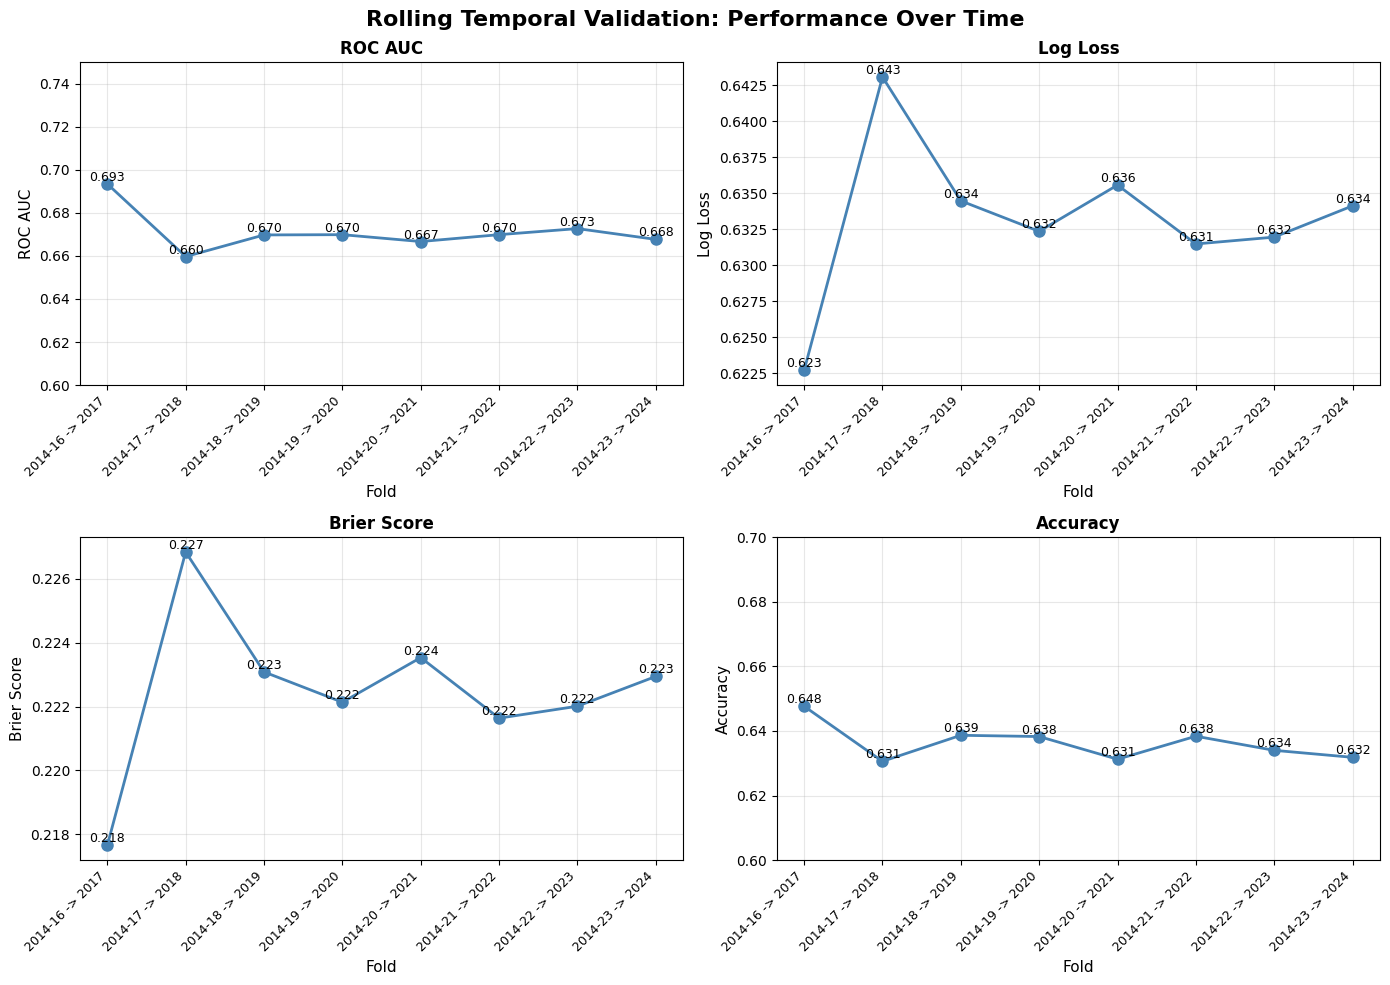

In [13]:
# Plot metrics over time
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Rolling Temporal Validation: Performance Over Time', fontsize=16, fontweight='bold')

metrics = [
    ('auc', 'ROC AUC', axes[0, 0], (0.6, 0.75)),
    ('log_loss', 'Log Loss', axes[0, 1], None),
    ('brier', 'Brier Score', axes[1, 0], None),
    ('accuracy', 'Accuracy', axes[1, 1], (0.6, 0.7))
]

for metric_col, metric_name, ax, ylim in metrics:
    ax.plot(range(len(results_df)), results_df[metric_col], 
            marker='o', markersize=8, linewidth=2, color='steelblue')
    ax.set_xlabel('Fold', fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(metric_name, fontsize=12, fontweight='bold')
    ax.set_xticks(range(len(results_df)))
    ax.set_xticklabels(results_df['fold'], rotation=45, ha='right', fontsize=9)
    ax.grid(True, alpha=0.3)
    if ylim:
        ax.set_ylim(ylim)
    
    # Add value labels
    for i, val in enumerate(results_df[metric_col]):
        ax.text(i, val, f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Export Results

In [14]:
# Export detailed results
output_file = 'rolling_temporal_validation_results.csv'
results_df.to_csv(output_file, index=False)
print(f"Results saved to: {output_file}")

# Print summary statistics
print("\n" + "="*80)
print("INTERPRETATION")
print("="*80)
print("""
Key Findings:

1. **Temporal Stability**: Model maintains consistent performance across years
   - AUC stays in 0.65-0.69 range across all folds
   - Features generalize well to future seasons (no major drift)

2. **Training Data Benefits**: More data provides modest improvement
   - Compare 2014-16 -> 2017 (3 years training) vs 2014-23 -> 2024 (10 years)
   - Diminishing returns after ~1M training samples

3. **Actual Performance**:
   - AUC: 0.65-0.69 (realistic shot quality prediction)
   - Accuracy: 62-65%
   - Log Loss: 0.62-0.65

4. **Red Flags** (if you see these, investigate!):
   - AUC > 0.75: Possible data leakage - check features!
   - AUC < 0.60: Features may not capture shot quality
   - Large variance across folds: Unstable model or distribution shift

5. **Why Not Higher?**
   - Shot outcomes have inherent randomness (even open shots miss ~45% of the time)
   - Without defender tracking data, contest estimation is approximate
   - Player skill varies game-to-game (hot/cold streaks)
   - Rule changes and play style evolution between seasons
""")
print("="*80)

Results saved to: rolling_temporal_validation_results.csv

INTERPRETATION

Key Findings:

1. **Temporal Stability**: Model maintains consistent performance across years
   - AUC stays in 0.65-0.69 range across all folds
   - Features generalize well to future seasons (no major drift)

2. **Training Data Benefits**: More data provides modest improvement
   - Compare 2014-16 -> 2017 (3 years training) vs 2014-23 -> 2024 (10 years)
   - Diminishing returns after ~1M training samples

3. **Actual Performance**:
   - AUC: 0.65-0.69 (realistic shot quality prediction)
   - Accuracy: 62-65%
   - Log Loss: 0.62-0.65

4. **Red Flags** (if you see these, investigate!):
   - AUC > 0.75: Possible data leakage - check features!
   - AUC < 0.60: Features may not capture shot quality
   - Large variance across folds: Unstable model or distribution shift

5. **Why Not Higher?**
   - Shot outcomes have inherent randomness (even open shots miss ~45% of the time)
   - Without defender tracking data, cont

## Data Requirements

This notebook requires enriched shot data for seasons 2013-14 through 2024-25:
- `enriched_data/nbastatsv3_2013_enriched_shots.csv`
- `enriched_data/nbastatsv3_2014_enriched_shots.csv`
- ... through ...
- `enriched_data/nbastatsv3_2024_enriched_shots.csv`

Run `enrich_shots_nbastatsv3_full.ipynb` to generate these files from raw NBA Stats v3 data.